## README:

This notebook serves the following purposes:
* Visually examine data timeseries
* Trim starting / ending dates of data, and discard series with too little data
* Map data to the full range of dates and imputes missing data
* Resample series of different frequencies and merge

**NOTE**: Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually 

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import reduce
from dotenv import load_dotenv

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [3]:
from data_processing.utils import get_indices_of_first_datapoint

## Load env variables

In [4]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Global config

In [5]:
## ----- CONFIG ----- ##
WRITE_MODE = 'w' # 'x': do not overwrite

## Examine and clean raw data

### FRED

In [6]:
from data_processing.fred_api import processing_steps as proc

In [7]:
## ----- CONFIG ----- ##
FRED_VERSION = '001' # version of downloaded data to read

# specify frequencies of each series
# find frequencies on https://fred.stlouisfed.org/categories
# NOTE: series without frequency info will be skipped
SERIES_FREQ = {
    'VIXCLS': 'D',
    'DFF': 'D',
    'T10Y2Y': 'D',
    'REAINTRATREARAT10Y': 'MS',
    'BAMLH0A0HYM2': 'D',
    'CPIAUCSL': 'MS',
    'ICSA': 'W-SAT',
    'PPIACO': 'MS',
    'USSTHPI': 'QS',
    'BOGMBASE': 'MS',
    'DTWEXBGS': 'D',
    'USREC': 'MS',
    'USSLIND': 'MS',
    'USEPUINDXD': 'D'
}

In [8]:
# load FRED data files
# (all files of the specified version will be loaded)
pattern = os.path.join(DATA_DIR, 'FRED', f'*_{FRED_VERSION}.csv')
fred_files = glob.glob(pattern)
len(fred_files)

14

===== Processing BAMLH0A0HYM2 =====
	Step: format | Rows: 7648 | NA count: 92 | NA %: 1.2
	Step: expand dates | Rows: 10570 | NA count: 3014 | NA %: 28.51
	Step: impute | Rows: 7648 | NA count: 0 | NA %: 0.0
===== Processing BOGMBASE =====
	Step: format | Rows: 610 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 610 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 610 | NA count: 0 | NA %: 0.0
===== Processing CPIAUCSL =====
	Step: format | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 609 | NA count: 0 | NA %: 0.0
===== Processing DFF =====
	Step: format | Rows: 18605 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 18605 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 18605 | NA count: 0 | NA %: 0.0
===== Processing DTWEXBGS =====
	Step: format | Rows: 5200 | NA count: 204 | NA %: 3.92
	Step: expand dates | Rows: 7278 | NA count: 2282 | NA %: 31.35
	Step: impute | Rows: 5200 | NA count: 0 | NA %: 0.0
====

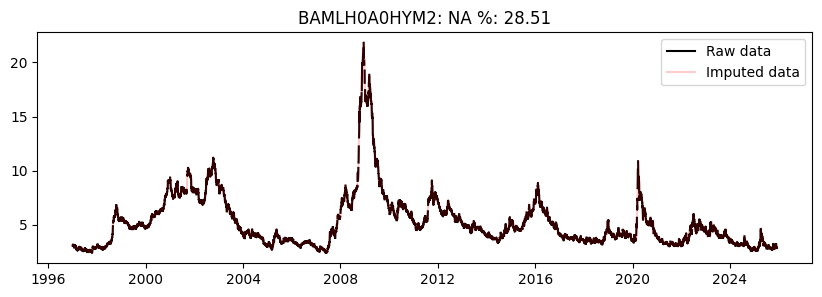

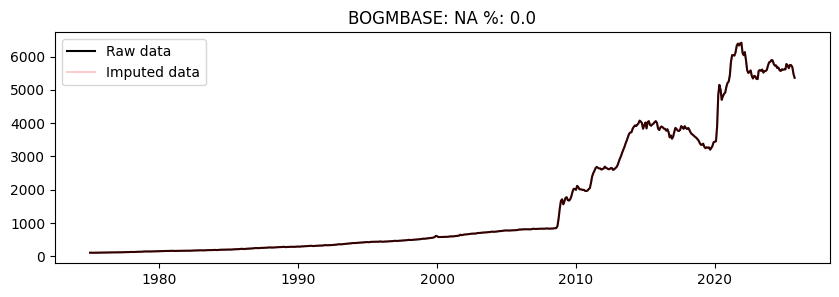

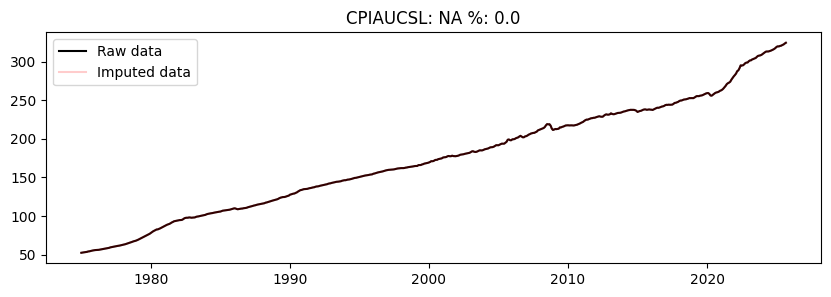

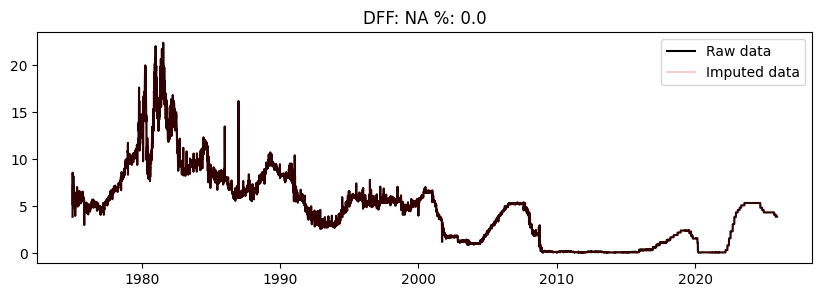

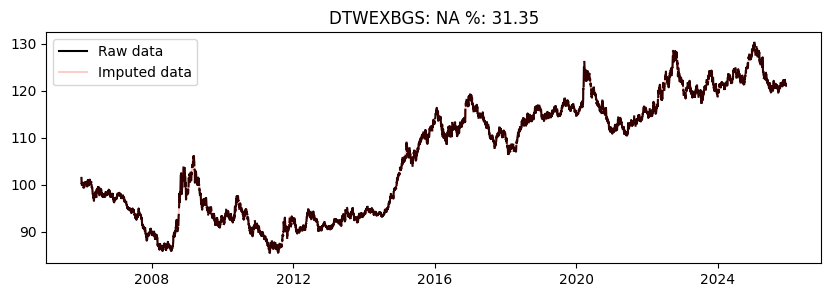

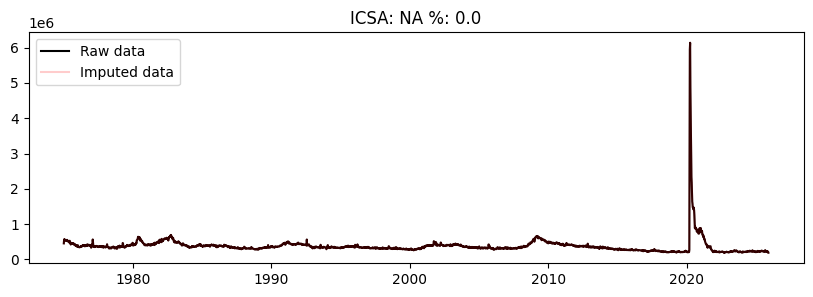

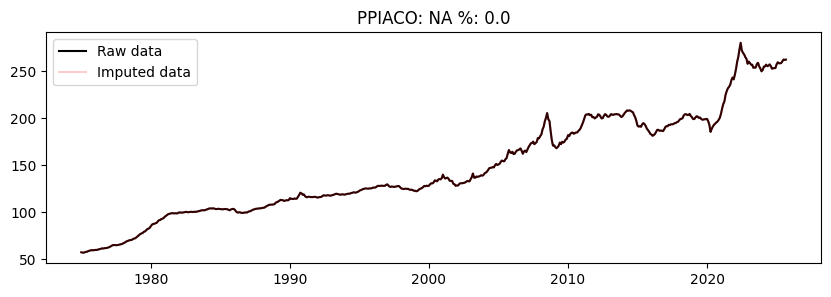

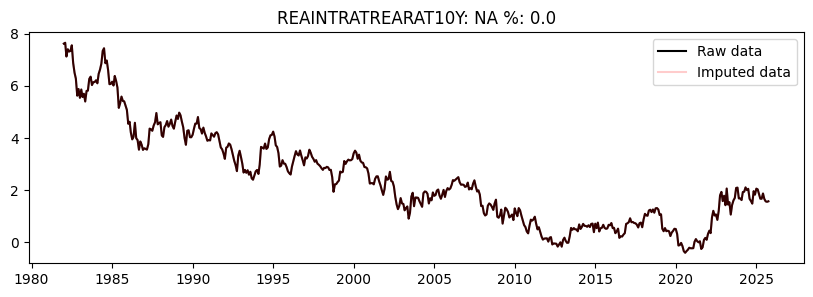

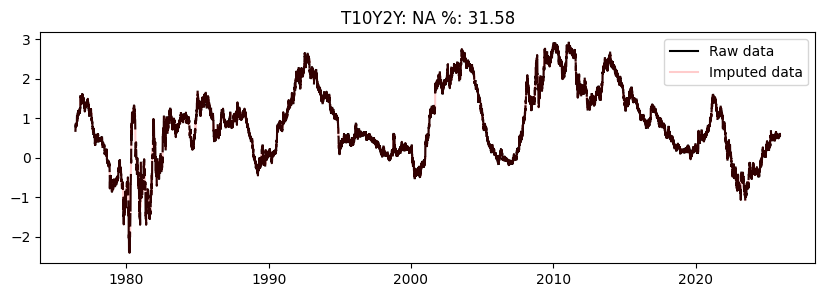

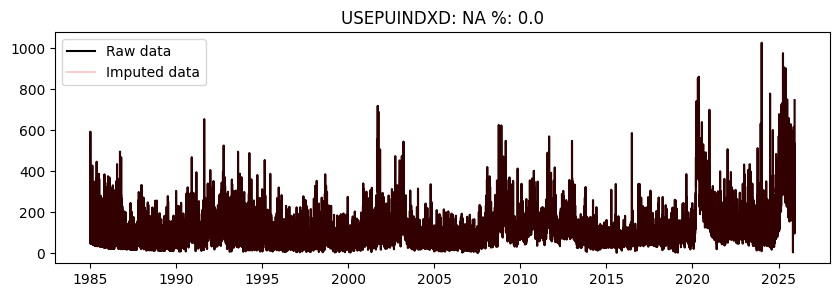

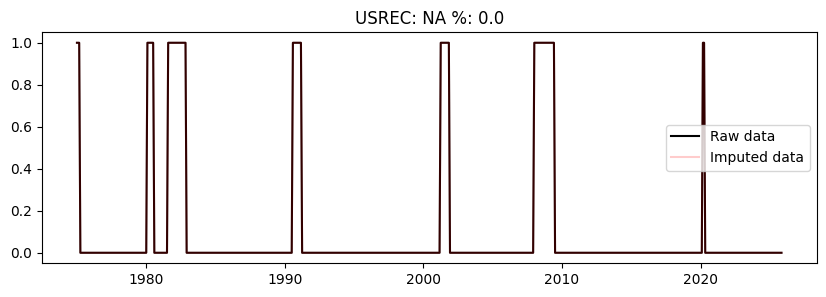

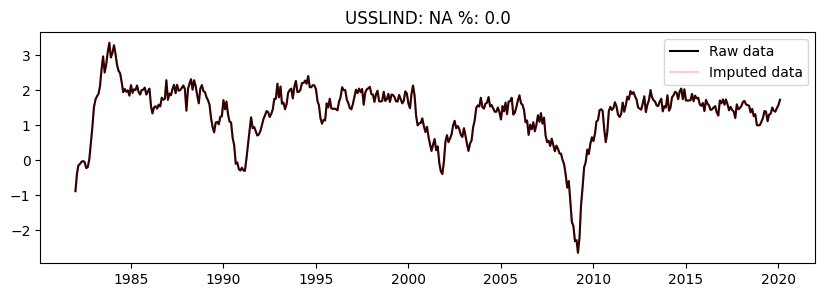

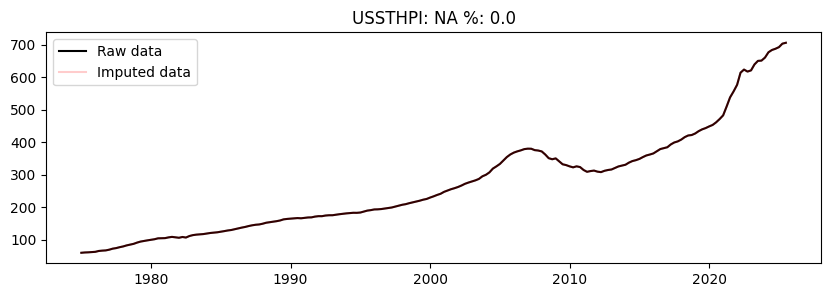

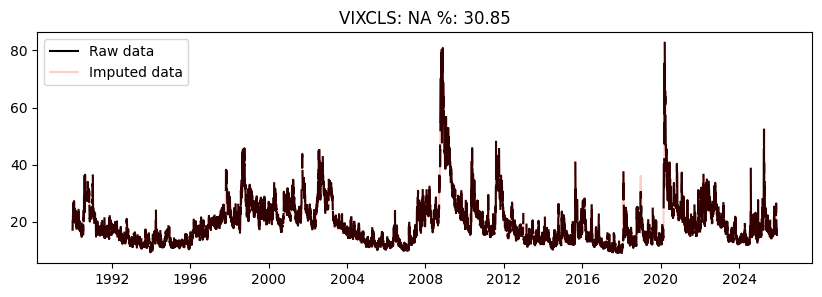

In [9]:
# read data
fred_data = dict()

for file in fred_files:
    series_id = os.path.basename(file).split('_')[0]

    if series_id not in SERIES_FREQ:
        print(f'Skipping {series_id} as data frequency is not specified.')
        continue

    print(f'===== Processing {series_id} =====')

    df = pd.read_csv(file)

    # apply pre-processing steps
    df = proc.format_raw_series(series_id, df)
    df_expanded = proc.expand_full_dates(df, freq=SERIES_FREQ[series_id])
    df_imputed = proc.impute_missing_data(series_id, df)

    # plot original data + imputed segments
    na_perc = round(df_expanded.isna().mean().values[0]*100, 2)
    fig, ax = plt.subplots(figsize=(10,3))
    ax.set_title(f"{series_id}: NA %: {na_perc}")
    ax.plot(df_expanded, label='Raw data', c='black')
    ax.plot(df_imputed, label='Imputed data', c='red', alpha=0.2)
    ax.legend()

    # store processed data
    fred_data[series_id] = df_imputed

In [10]:
# join all FRED series by date index
fred_df = reduce(lambda left, right: left.join(right, how='outer'), fred_data.values())
fred_df = fred_df.sort_index()
fred_df.shape

(18606, 14)

In [11]:
# resample to daily frequency by filling forward to avoid data leakage
fred_df = fred_df.ffill()

In [12]:
na_df = fred_df.isna()

# check NA % in each column
print(na_df.shape)
na_df.mean(axis=0).sort_values(ascending=False)

(18606, 14)


DTWEXBGS              0.608621
BAMLH0A0HYM2          0.431850
VIXCLS                0.294529
USEPUINDXD            0.196335
REAINTRATREARAT10Y    0.137429
USSLIND               0.137429
T10Y2Y                0.027787
ICSA                  0.000161
BOGMBASE              0.000000
DFF                   0.000000
CPIAUCSL              0.000000
PPIACO                0.000000
USREC                 0.000000
USSTHPI               0.000000
dtype: float64

In [13]:
get_indices_of_first_datapoint(na_df)

,first datapoint,column
4,2006-01-02,DTWEXBGS
0,1996-12-31,BAMLH0A0HYM2
13,1990-01-02,VIXCLS
9,1985-01-01,USEPUINDXD
11,1982-01-01,USSLIND
7,1982-01-01,REAINTRATREARAT10Y
8,1976-06-01,T10Y2Y
5,1975-01-04,ICSA
12,1975-01-01,USSTHPI
10,1975-01-01,USREC


In [ ]:
## ----- CONFIG ----- ##
# choose a start date (inclusive)
START_DATE = '1996-12-31'

# choose series to exclude (timeseries is too short)
EXCLUDE_IDS = [
    'DTWEXBGS'
]

In [15]:
# subset columns
cols_filter = ~fred_df.columns.isin(EXCLUDE_IDS)

# check NAs of subset
print('NAs detected:', na_df.loc[START_DATE:, cols_filter].any().any())
print('Data points per ticker:', fred_df.loc[START_DATE:, cols_filter].shape[0])

NAs detected: False
Data points per ticker: 10571


In [16]:
# apply filters
fred_df = fred_df.loc[START_DATE:, cols_filter]

### YFINANCE

In [17]:
## ----- CONFIG ----- ##
YF_VERSION = '001' # version of yfinance data to load

In [18]:
# get raw data
input_file = os.path.join(DATA_DIR, 'YFINANCE', f'prices_{YF_VERSION}.csv')
prices_df = pd.read_csv(input_file, header=[0,1], low_memory=False)

In [19]:
# check NAs in dates
dt_index = pd.to_datetime(prices_df['Date'].iloc[:,0])
dt_index.name = 'date'

print('NAs detected:', any(dt_index.isna()))
print('Unique dates:', dt_index.nunique())
print('Date range:', dt_index.min(), dt_index.max())

NAs detected: False
Unique dates: 12843
Date range: 1975-01-02 00:00:00 2025-12-09 00:00:00


In [20]:
# set date index
prices_df = (
    prices_df
    .set_index(dt_index)
    .drop('Date', level=0, axis=1)
)

In [21]:
# check df attributes
print(prices_df.shape)

price_types = sorted(set(prices_df.columns.get_level_values(0)))
print(price_types)

tics = sorted(set(prices_df.columns.get_level_values(1)))
print(tics)

# sort by column levels
prices_df = prices_df.sort_index(axis=1, level=[0, 1])

(12843, 55)
['Close', 'High', 'Low', 'Open', 'Volume']
['AAPL', 'AMZN', 'F', 'GOOG', 'JPM', 'MSFT', 'NVDA', 'PG', 'SPY', 'UNH', 'XOM']


In [22]:
na_df = prices_df.isna()

get_indices_of_first_datapoint(na_df['Close'])

,first datapoint,column
3,2004-08-19,GOOG
6,1999-01-22,NVDA
1,1997-05-15,AMZN
8,1993-01-29,SPY
5,1986-03-13,MSFT
9,1984-10-17,UNH
0,1980-12-12,AAPL
4,1980-03-17,JPM
10,1975-01-02,XOM
7,1975-01-02,PG


In [ ]:
## ----- CONFIG ----- ##
# choose a start date (inclusive)
START_DATE = '1999-01-22'

# choose tickers to exclude (timeseries is too short)
EXCLUDE_TICS = [
    'GOOG',
]

In [24]:
# subset columns
cols_filter = ~prices_df.columns.get_level_values(1).isin(EXCLUDE_TICS)

# check NAs of subset
print('NAs detected:', na_df.loc[START_DATE:, cols_filter].any().any())
print('Data points per ticker:', prices_df.loc[START_DATE:, cols_filter].shape[0])

NAs detected: False
Data points per ticker: 6763


In [25]:
# get subset of data with conditions on start date and excluded tickers
sub_prices_df = prices_df.loc[START_DATE:, cols_filter]

# restructure prices DF
sub_prices_df = (
    sub_prices_df
    .stack(level=1, future_stack=True)
    .reset_index(level=1)
    .rename({'level_1': 'tic'}, axis=1)
)

# rename columns
sub_prices_df.columns = [col.lower() for col in sub_prices_df.columns]

print(sub_prices_df.shape)
sub_prices_df.head()

(67630, 6)


,tic,close,high,low,open,volume
date,,,,,,
1999-01-22,AAPL,0.290538,0.296162,0.277886,0.282572,345766400.0
1999-01-22,AMZN,3.075000,3.146875,2.468750,2.487500,875316000.0
1999-01-22,F,12.919081,13.078248,12.839498,13.078248,5574435.0
1999-01-22,JPM,22.352213,23.168555,22.274465,22.974187,7715700.0
1999-01-22,MSFT,23.861567,24.470036,23.708853,23.766120,82160000.0


## Combine data

In [26]:
joined_df = (
    sub_prices_df
    .join(fred_df, how='inner') # inner join exclude dates without stock prices (e.g. weekends)
    .reset_index()
    .rename({'index': 'date'}, axis=1)
    .sort_values(['tic', 'date'])
)

# check NAs
joined_na_df = joined_df.isna()
print('NAs detected:', joined_na_df.any().any())
print('Data points per ticker:', joined_df.shape[0] / joined_df['tic'].nunique())

NAs detected: False
Data points per ticker: 6763.0


In [27]:
# preview data
joined_df.head()

,date,tic,close,high,low,open,volume,BAMLH0A0HYM2,BOGMBASE,CPIAUCSL,DFF,ICSA,PPIACO,REAINTRATREARAT10Y,T10Y2Y,USEPUINDXD,USREC,USSLIND,USSTHPI,VIXCLS
0,1999-01-22,AAPL,0.290538,0.296162,0.277886,0.282572,345766400.0,5.59,527.9,164.7,4.62,339000.0,122.9,2.308152,0.05,87.33,0.0,1.66,217.23,31.95
10,1999-01-25,AAPL,0.295225,0.296630,0.291007,0.294287,385336000.0,5.56,527.9,164.7,4.97,311000.0,122.9,2.308152,0.08,64.16,0.0,1.66,217.23,31.13
20,1999-01-26,AAPL,0.303659,0.306471,0.297099,0.299442,560044800.0,5.54,527.9,164.7,4.84,311000.0,122.9,2.308152,0.06,51.50,0.0,1.66,217.23,29.23
30,1999-01-27,AAPL,0.300848,0.310220,0.299442,0.307408,364952000.0,5.54,527.9,164.7,4.61,311000.0,122.9,2.308152,0.11,75.69,0.0,1.66,217.23,29.73
40,1999-01-28,AAPL,0.306471,0.309283,0.302253,0.306471,336280000.0,5.53,527.9,164.7,4.80,311000.0,122.9,2.308152,0.09,68.09,0.0,1.66,217.23,28.11


In [28]:
# export data
out_path = os.path.join(DATA_DIR, 'preprocessed.csv')
joined_df.to_csv(out_path, index=False, mode=WRITE_MODE)